<a href="https://colab.research.google.com/github/OJB-Quantum/Notebooks-for-Ideas/blob/main/Top_50_Value_Creators_of_2026_by_Presence_in_the_US.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Authored by Onri Jay Benally (2026)

Open Access (CC-BY-4.0)

In [2]:
"""
Module for generating markdown tables of the top fifty value creators.

This script utilizes the pandas library to structure and output data
concerning the Boston Consulting Group (BCG) 2026 top value creators,
categorizing them by their operational presence within the United States (US).
"""

# Install the necessary pandas library prior to execution using pip or uv.
# pip install pandas
# uv pip install pandas

import pandas as pd

# ==========================================================================
# CONTROL KNOBS
# ==========================================================================
# Toggle to enable or disable the printing of the markdown output.
ENABLE_MARKDOWN_OUTPUT = True
# Toggle to sort the resulting dataframes numerically by their assigned rank.
SORT_BY_RANK = True
# Toggle to include the geographical headquarters location in the output.
INCLUDE_HEADQUARTERS = True
# ==========================================================================

def generate_markdown_tables() -> None:
    """
    Process the corporate data and generate formatted markdown tables.

    This function constructs a pandas DataFrame from a predefined list of
    dictionaries containing corporate rankings, names, headquarters, and
    their United States presence status. It applies filtering based on the
    global control parameters and prints the resulting markdown tables to
    the standard output.
    """
    # Define the raw dataset containing the ranking and geographical details.
    data = [
        {"Rank": "01", "Company": "NVIDIA", "Headquarters": "US", "US_Presence": True},
        {"Rank": "02", "Company": "UniCredit", "Headquarters": "Italy", "US_Presence": True},
        {"Rank": "03", "Company": "Rolls-Royce", "Headquarters": "UK", "US_Presence": True},
        {"Rank": "04", "Company": "Broadcom", "Headquarters": "US", "US_Presence": True},
        {"Rank": "05", "Company": "Palantir Technologies", "Headquarters": "US", "US_Presence": True},
        {"Rank": "06", "Company": "Arista Networks", "Headquarters": "US", "US_Presence": True},
        {"Rank": "07", "Company": "Eli Lilly", "Headquarters": "US", "US_Presence": True},
        {"Rank": "08", "Company": "Hitachi", "Headquarters": "Japan", "US_Presence": True},
        {"Rank": "09", "Company": "Mitsubishi UFJ Financial", "Headquarters": "Japan", "US_Presence": True},
        {"Rank": "10", "Company": "BBVA", "Headquarters": "Spain", "US_Presence": True},
        {"Rank": "11", "Company": "Sumitomo Mitsui Financial", "Headquarters": "Japan", "US_Presence": True},
        {"Rank": "12", "Company": "GE Aerospace", "Headquarters": "US", "US_Presence": True},
        {"Rank": "13", "Company": "SK Hynix", "Headquarters": "South Korea", "US_Presence": True},
        {"Rank": "14", "Company": "PetroChina", "Headquarters": "China", "US_Presence": True},
        {"Rank": "15", "Company": "Foxconn", "Headquarters": "Taiwan", "US_Presence": True},
        {"Rank": "16", "Company": "CNOOC", "Headquarters": "China", "US_Presence": True},
        {"Rank": "17", "Company": "KLA", "Headquarters": "US", "US_Presence": True},
        {"Rank": "18", "Company": "China Shenhua Energy", "Headquarters": "China", "US_Presence": False},
        {"Rank": "19", "Company": "McKesson", "Headquarters": "US", "US_Presence": True},
        {"Rank": "20", "Company": "Intesa Sanpaolo", "Headquarters": "Italy", "US_Presence": True},
        {"Rank": "21", "Company": "Banco Santander", "Headquarters": "Spain", "US_Presence": True},
        {"Rank": "22", "Company": "Amphenol", "Headquarters": "US", "US_Presence": True},
        {"Rank": "23", "Company": "Bharti Airtel", "Headquarters": "India", "US_Presence": True},
        {"Rank": "24", "Company": "HSBC", "Headquarters": "UK", "US_Presence": True},
        {"Rank": "25", "Company": "Zijin Mining", "Headquarters": "China", "US_Presence": False},
        {"Rank": "26", "Company": "Siemens Energy", "Headquarters": "Germany", "US_Presence": True},
        {"Rank": "27", "Company": "Micron Technology", "Headquarters": "US", "US_Presence": True},
        {"Rank": "28", "Company": "State Bank of India", "Headquarters": "India", "US_Presence": True},
        {"Rank": "29", "Company": "Lam Research", "Headquarters": "US", "US_Presence": True},
        {"Rank": "30", "Company": "UBS", "Headquarters": "Switzerland", "US_Presence": True},
        {"Rank": "31", "Company": "Goldman Sachs", "Headquarters": "US", "US_Presence": True},
        {"Rank": "32", "Company": "Alphabet", "Headquarters": "US", "US_Presence": True},
        {"Rank": "33", "Company": "Exxon Mobil", "Headquarters": "US", "US_Presence": True},
        {"Rank": "34", "Company": "Wells Fargo", "Headquarters": "US", "US_Presence": True},
        {"Rank": "35", "Company": "Caterpillar", "Headquarters": "US", "US_Presence": True},
        {"Rank": "36", "Company": "Parker-Hannifin", "Headquarters": "US", "US_Presence": True},
        {"Rank": "37", "Company": "KKR", "Headquarters": "US", "US_Presence": True},
        {"Rank": "38", "Company": "Welltower", "Headquarters": "US", "US_Presence": True},
        {"Rank": "39", "Company": "American Express", "Headquarters": "US", "US_Presence": True},
        {"Rank": "40", "Company": "Oracle", "Headquarters": "US", "US_Presence": True},
        {"Rank": "41", "Company": "Agricultural Bank of China", "Headquarters": "China", "US_Presence": True},
        {"Rank": "42", "Company": "DBS", "Headquarters": "Singapore", "US_Presence": True},
        {"Rank": "43", "Company": "TSMC", "Headquarters": "Taiwan", "US_Presence": True},
        {"Rank": "44", "Company": "ABB", "Headquarters": "Switzerland", "US_Presence": True},
        {"Rank": "45", "Company": "Palo Alto Networks", "Headquarters": "US", "US_Presence": True},
        {"Rank": "46", "Company": "Applied Materials", "Headquarters": "US", "US_Presence": True},
        {"Rank": "47", "Company": "Hon Hai Precision Industry", "Headquarters": "Taiwan", "US_Presence": True},
        {"Rank": "48", "Company": "Morgan Stanley", "Headquarters": "US", "US_Presence": True},
        {"Rank": "49", "Company": "Tokyo Electron", "Headquarters": "Japan", "US_Presence": True},
        {"Rank": "50", "Company": "IBM", "Headquarters": "US", "US_Presence": True}
    ]

    # Instantiate the primary DataFrame using the collected data.
    df = pd.DataFrame(data)

    # Reorder the DataFrame according to the numerical rank if the configuration dictates it.
    if SORT_BY_RANK:
        df = df.sort_values(by="Rank")

    # Eliminate the headquarters column from the DataFrame when the control parameter is deactivated.
    if not INCLUDE_HEADQUARTERS:
        df = df.drop(columns=["Headquarters"])

    # Isolate the corporations maintaining a physical presence within the United States.
    df_us_presence = df[df["US_Presence"] == True].drop(columns=["US_Presence"])

    # Isolate the corporations operating strictly externally to the United States.
    df_no_us_presence = df[df["US_Presence"] == False].drop(columns=["US_Presence"])

    # Output the formatted markdown tables to the console when the designated flag is enabled.
    if ENABLE_MARKDOWN_OUTPUT:
        print("United States Companies and International Companies with a United States Presence")
        print(df_us_presence.to_markdown(index=False))
        print("\nInternational Companies without a United States Presence")
        print(df_no_us_presence.to_markdown(index=False))

if __name__ == "__main__":
    generate_markdown_tables()

United States Companies and International Companies with a United States Presence
|   Rank | Company                    | Headquarters   |
|-------:|:---------------------------|:---------------|
|     01 | NVIDIA                     | US             |
|     02 | UniCredit                  | Italy          |
|     03 | Rolls-Royce                | UK             |
|     04 | Broadcom                   | US             |
|     05 | Palantir Technologies      | US             |
|     06 | Arista Networks            | US             |
|     07 | Eli Lilly                  | US             |
|     08 | Hitachi                    | Japan          |
|     09 | Mitsubishi UFJ Financial   | Japan          |
|     10 | BBVA                       | Spain          |
|     11 | Sumitomo Mitsui Financial  | Japan          |
|     12 | GE Aerospace               | US             |
|     13 | SK Hynix                   | South Korea    |
|     14 | PetroChina                 | China          |
|     

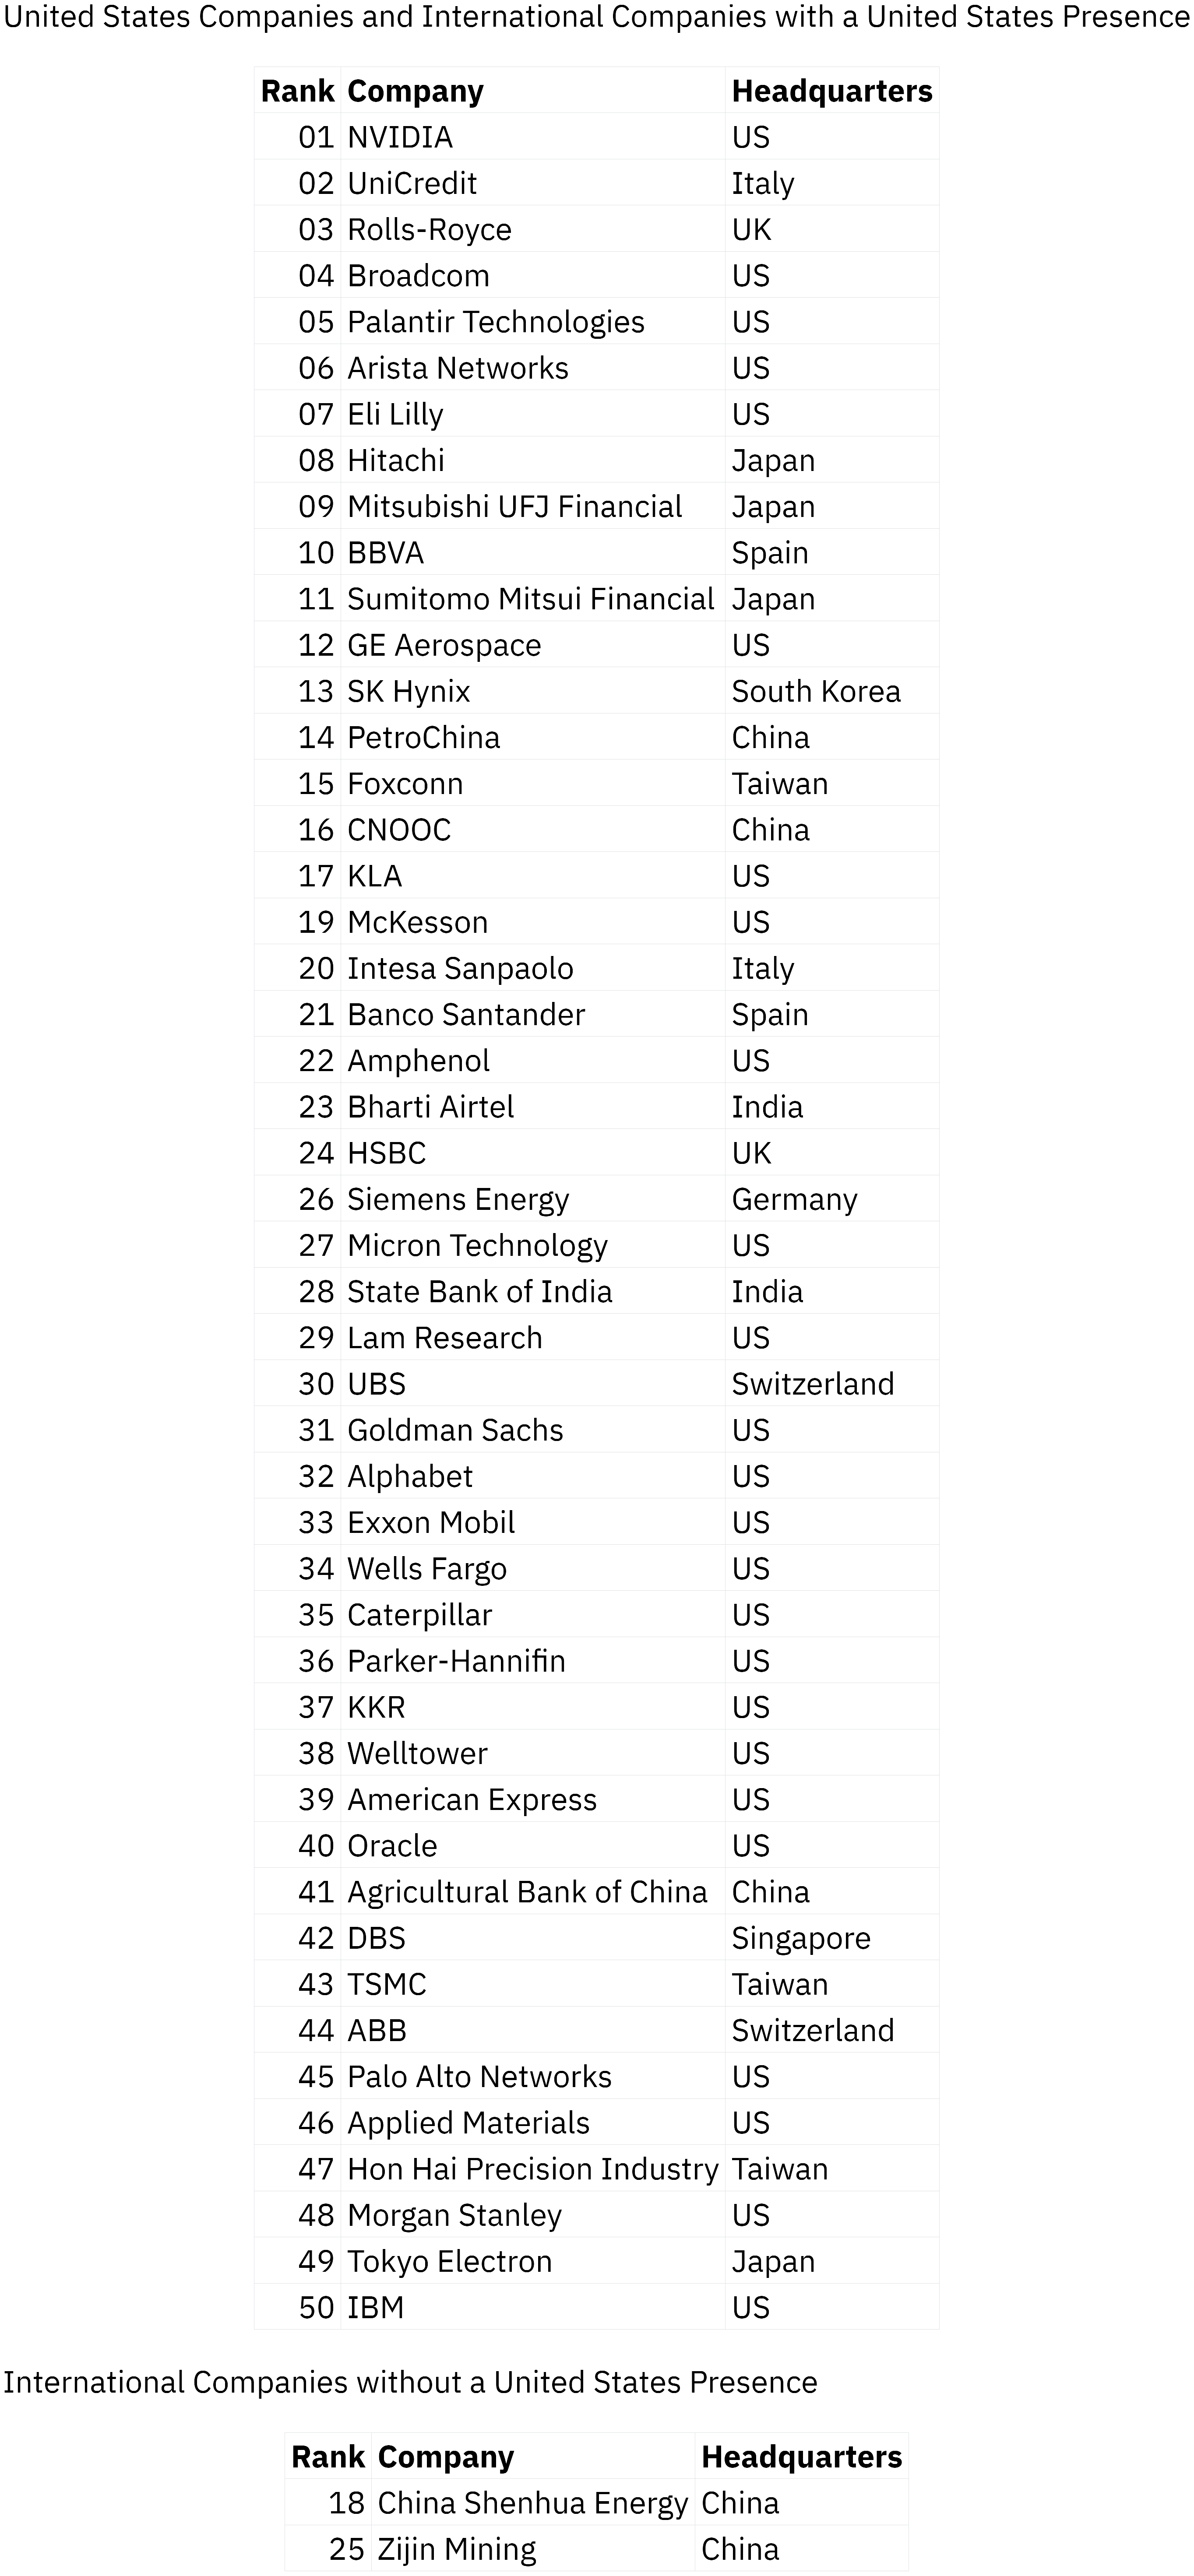

In [4]:
"""
Module for rendering an interactive data table within Google Colab.

This script leverages the pandas library alongside the native Google
Colaboratory Application Programming Interface (API) to generate a
paginated, interactive GUI table representing the Boston Consulting Group (BCG)
2026 top value creators.
"""

# The user installs the necessary pandas library prior to execution.
# pip install pandas
# uv pip install pandas

import pandas as pd

# The script attempts to import environment-specific rendering modules.
try:
    from google.colab import data_table
    from IPython.display import display
    COLAB_ENVIRONMENT_ACTIVE = True
except ImportError:
    COLAB_ENVIRONMENT_ACTIVE = False

# ==========================================================================
# CONTROL KNOBS
# ==========================================================================
# Toggle to enable the interactive Graphical User Interface (GUI) rendering.
ENABLE_INTERACTIVE_GUI = True
# Define the integer quantity of rows displayed per paginated view.
ROWS_PER_PAGE = 15
# ==========================================================================

def render_colab_table() -> None:
    """
    Construct and display an interactive table within the notebook environment.

    The function initializes a pandas DataFrame using the corporate data and
    subsequently passes this structured data to the Google Colaboratory
    data_table module. This process generates an interactive Graphical User
    Interface (GUI) element allowing for advanced data exploration directly
    within the output cell.
    """
    data = [
        {"Rank": "01", "Company": "NVIDIA", "Headquarters": "US", "US_Presence": True},
        {"Rank": "02", "Company": "UniCredit", "Headquarters": "Italy", "US_Presence": True},
        {"Rank": "03", "Company": "Rolls-Royce", "Headquarters": "UK", "US_Presence": True},
        {"Rank": "04", "Company": "Broadcom", "Headquarters": "US", "US_Presence": True},
        {"Rank": "05", "Company": "Palantir Technologies", "Headquarters": "US", "US_Presence": True},
        {"Rank": "06", "Company": "Arista Networks", "Headquarters": "US", "US_Presence": True},
        {"Rank": "07", "Company": "Eli Lilly", "Headquarters": "US", "US_Presence": True},
        {"Rank": "08", "Company": "Hitachi", "Headquarters": "Japan", "US_Presence": True},
        {"Rank": "09", "Company": "Mitsubishi UFJ Financial", "Headquarters": "Japan", "US_Presence": True},
        {"Rank": "10", "Company": "BBVA", "Headquarters": "Spain", "US_Presence": True},
        {"Rank": "11", "Company": "Sumitomo Mitsui Financial", "Headquarters": "Japan", "US_Presence": True},
        {"Rank": "12", "Company": "GE Aerospace", "Headquarters": "US", "US_Presence": True},
        {"Rank": "13", "Company": "SK Hynix", "Headquarters": "South Korea", "US_Presence": True},
        {"Rank": "14", "Company": "PetroChina", "Headquarters": "China", "US_Presence": True},
        {"Rank": "15", "Company": "Foxconn", "Headquarters": "Taiwan", "US_Presence": True},
        {"Rank": "16", "Company": "CNOOC", "Headquarters": "China", "US_Presence": True},
        {"Rank": "17", "Company": "KLA", "Headquarters": "US", "US_Presence": True},
        {"Rank": "18", "Company": "China Shenhua Energy", "Headquarters": "China", "US_Presence": False},
        {"Rank": "19", "Company": "McKesson", "Headquarters": "US", "US_Presence": True},
        {"Rank": "20", "Company": "Intesa Sanpaolo", "Headquarters": "Italy", "US_Presence": True},
        {"Rank": "21", "Company": "Banco Santander", "Headquarters": "Spain", "US_Presence": True},
        {"Rank": "22", "Company": "Amphenol", "Headquarters": "US", "US_Presence": True},
        {"Rank": "23", "Company": "Bharti Airtel", "Headquarters": "India", "US_Presence": True},
        {"Rank": "24", "Company": "HSBC", "Headquarters": "UK", "US_Presence": True},
        {"Rank": "25", "Company": "Zijin Mining", "Headquarters": "China", "US_Presence": False},
        {"Rank": "26", "Company": "Siemens Energy", "Headquarters": "Germany", "US_Presence": True},
        {"Rank": "27", "Company": "Micron Technology", "Headquarters": "US", "US_Presence": True},
        {"Rank": "28", "Company": "State Bank of India", "Headquarters": "India", "US_Presence": True},
        {"Rank": "29", "Company": "Lam Research", "Headquarters": "US", "US_Presence": True},
        {"Rank": "30", "Company": "UBS", "Headquarters": "Switzerland", "US_Presence": True},
        {"Rank": "31", "Company": "Goldman Sachs", "Headquarters": "US", "US_Presence": True},
        {"Rank": "32", "Company": "Alphabet", "Headquarters": "US", "US_Presence": True},
        {"Rank": "33", "Company": "Exxon Mobil", "Headquarters": "US", "US_Presence": True},
        {"Rank": "34", "Company": "Wells Fargo", "Headquarters": "US", "US_Presence": True},
        {"Rank": "35", "Company": "Caterpillar", "Headquarters": "US", "US_Presence": True},
        {"Rank": "36", "Company": "Parker-Hannifin", "Headquarters": "US", "US_Presence": True},
        {"Rank": "37", "Company": "KKR", "Headquarters": "US", "US_Presence": True},
        {"Rank": "38", "Company": "Welltower", "Headquarters": "US", "US_Presence": True},
        {"Rank": "39", "Company": "American Express", "Headquarters": "US", "US_Presence": True},
        {"Rank": "40", "Company": "Oracle", "Headquarters": "US", "US_Presence": True},
        {"Rank": "41", "Company": "Agricultural Bank of China", "Headquarters": "China", "US_Presence": True},
        {"Rank": "42", "Company": "DBS", "Headquarters": "Singapore", "US_Presence": True},
        {"Rank": "43", "Company": "TSMC", "Headquarters": "Taiwan", "US_Presence": True},
        {"Rank": "44", "Company": "ABB", "Headquarters": "Switzerland", "US_Presence": True},
        {"Rank": "45", "Company": "Palo Alto Networks", "Headquarters": "US", "US_Presence": True},
        {"Rank": "46", "Company": "Applied Materials", "Headquarters": "US", "US_Presence": True},
        {"Rank": "47", "Company": "Hon Hai Precision Industry", "Headquarters": "Taiwan", "US_Presence": True},
        {"Rank": "48", "Company": "Morgan Stanley", "Headquarters": "US", "US_Presence": True},
        {"Rank": "49", "Company": "Tokyo Electron", "Headquarters": "Japan", "US_Presence": True},
        {"Rank": "50", "Company": "IBM", "Headquarters": "US", "US_Presence": True}
    ]

    df = pd.DataFrame(data)

    if ENABLE_INTERACTIVE_GUI and COLAB_ENVIRONMENT_ACTIVE:
        interactive_table = data_table.DataTable(
            df,
            include_index=False,
            num_rows_per_page=ROWS_PER_PAGE
        )
        display(interactive_table)
    elif ENABLE_INTERACTIVE_GUI and not COLAB_ENVIRONMENT_ACTIVE:
        print("Colab environment undetected. Outputting standard text representation.")
        print(df.to_string())

if __name__ == "__main__":
    render_colab_table()

,Rank,Company,Headquarters,US_Presence
0,01,NVIDIA,US,True
1,02,UniCredit,Italy,True
2,03,Rolls-Royce,UK,True
3,04,Broadcom,US,True
4,05,Palantir Technologies,US,True
5,06,Arista Networks,US,True
6,07,Eli Lilly,US,True
7,08,Hitachi,Japan,True
8,09,Mitsubishi UFJ Financial,Japan,True
9,10,BBVA,Spain,True
